In [1]:
import torch
import torchvision
import numpy as np
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from sklearn.metrics import confusion_matrix
from torch.utils.data import DataLoader, random_split

In [2]:
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Dataset path
dataset_path = "/kaggle/input/odir-5k-org-full-cataract-classification/Cataract Classification"
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# # Enhanced data augmentation and normalization
# train_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # More aggressive cropping
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),  # Increased rotation
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
#     transforms.RandomGrayscale(p=0.1),  # Occasional grayscale
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Random erasing
# ])

# # Validation and test transforms (no augmentation)
# val_transform = transforms.Compose([
#     transforms.Resize((256, 256)),
#     transforms.CenterCrop(224),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# train_transform = transforms.Compose([
#     transforms.Resize((224, 224)),  # Slightly larger for EfficientNet
#     transforms.RandomResizedCrop(256, scale=(0.7, 1.0)),  # More aggressive cropping
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomVerticalFlip(),
#     transforms.RandomRotation(20),  # Increased rotation
#     transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
#     transforms.RandomGrayscale(p=0.1),  # Occasional grayscale
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3))  # Random erasing
# ])

# train_transform = transforms.Compose([
#     # First resize to larger size to enable meaningful crops
#     transforms.Resize(256),  # Resize to 256x256 first
    
#     # Then crop random 224x224 patches from the resized image
#     transforms.RandomResizedCrop(
#         224, 
#         scale=(0.8, 1.0),
#         ratio=(0.9, 1.1)  # Slightly constrain aspect ratios
#     ),
    
#     transforms.RandomHorizontalFlip(p=0.5),
    
#     # Color jitter before normalization
#     transforms.ColorJitter(
#         brightness=0.15,  # Slightly increased for ResNet
#         contrast=0.15,
#         saturation=0.15,
#         hue=0.05
#     ),
    
#     transforms.ToTensor(),
    
#     # Normalize with ImageNet stats
#     transforms.Normalize(
#         mean=[0.485, 0.456, 0.406],
#         std=[0.229, 0.224, 0.225]
#     ),
    
#     # RandomErasing should use default ImageNet-normalized values
#     transforms.RandomErasing(
#         p=0.15,  # Slightly higher probability
#         scale=(0.02, 0.1),
#         ratio=(0.3, 3.3),
#         value='random'  # Uses normalized ImageNet value ranges
#     )
# ])

# Train transforms (no augmentation)
# For ResNet50 (expects 224x224 input)
train_transform = transforms.Compose([
    transforms.Resize(256),          # First resize shorter side to 256
    transforms.CenterCrop(224),      # Then take 224x224 center crop
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Identical for validation/test
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# # Load dataset and create splits
# full_dataset = datasets.ImageFolder(root=dataset_path)

# # Create stratified splits to maintain class distribution

# # First split: 85% train+val, 15% test
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
# train_val_idx, test_idx = next(sss.split(np.zeros(len(full_dataset)), full_dataset.targets))

# train_val_dataset = torch.utils.data.Subset(full_dataset, train_val_idx)
# test_dataset = torch.utils.data.Subset(full_dataset, test_idx)

# # Second split: 85% train, 15% val from train_val
# sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
# train_idx, val_idx = next(sss.split(np.zeros(len(train_val_dataset)), [full_dataset.targets[i] for i in train_val_idx]))

# train_dataset = torch.utils.data.Subset(full_dataset, [train_val_idx[i] for i in train_idx])
# val_dataset = torch.utils.data.Subset(full_dataset, [train_val_idx[i] for i in val_idx])

# # Apply transforms
# train_dataset.dataset.transform = train_transform
# val_dataset.dataset.transform = val_transform
# test_dataset.dataset.transform = val_transform

# # DataLoaders
# batch_size = 32
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, 
#                          num_workers=4, pin_memory=True, drop_last=True)  # Drop last to avoid small batches
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)



# Load the full dataset
full_dataset = datasets.ImageFolder(root=dataset_path)

# Get targets for stratified splitting
targets = full_dataset.targets
n_total = len(targets)

# First split: 15% test, 85% train_val
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(sss1.split(np.zeros(n_total), targets))

# Second split: from 85% train_val, split 70% train and 15% val
# 70% out of total = ~82.35% of train_val; 15% out of total = ~17.65% of train_val
relative_val_size = 15 / (70 + 15)  # == 0.1765

train_val_targets = [targets[i] for i in train_val_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=relative_val_size, random_state=42)
train_idx, val_idx = next(sss2.split(np.zeros(len(train_val_targets)), train_val_targets))

# Get actual indices
train_dataset = Subset(full_dataset, [train_val_idx[i] for i in train_idx])
val_dataset = Subset(full_dataset, [train_val_idx[i] for i in val_idx])
test_dataset = Subset(full_dataset, test_idx)

# Assign transforms
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform
test_dataset.dataset.transform = val_transform

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=4, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


Using device: cuda


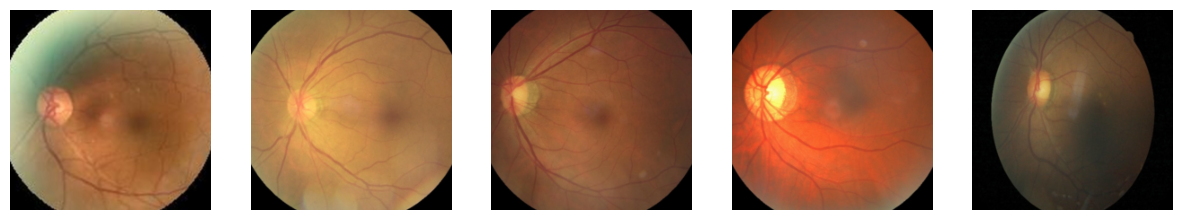

In [3]:
def visualize_augmentations(dataset, n=5):
    fig, axs = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        img, _ = dataset[i]
        img = img.numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        axs[i].imshow(img)
        axs[i].axis('off')
    plt.show()

visualize_augmentations(train_dataset)

In [4]:
# # Compute Class Distribution for Train-Validation Only
# num_classes = len(full_dataset.classes)
# labels = [full_dataset.targets[idx] for idx in train_val_dataset.indices]

# label_counts = Counter(labels)
# total_samples = sum(label_counts.values())

# # Compute Class Weights
# class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# class_names = full_dataset.classes
# print(class_weights)


# from collections import Counter

# # Combine train and val indices
# combined_indices = train_dataset.indices + val_dataset.indices
# combined_labels = [full_dataset.targets[idx] for idx in combined_indices]

# # Compute class distribution
# label_counts = Counter(combined_labels)
# total_samples = sum(label_counts.values())
# num_classes = len(full_dataset.classes)

# # Compute class weights
# class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
# class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# # For reference
# class_names = full_dataset.classes
# print("Class Weights:", class_weights)

# Calculate class weights ONLY on the training set (to avoid data leakage)
train_labels = [full_dataset.targets[i] for i in train_dataset.indices]
label_counts = Counter(train_labels)
total_samples = sum(label_counts.values())
num_classes = len(full_dataset.classes)

# Compute class weights using inverse frequency (balanced)
class_weights = [total_samples / (num_classes * label_counts[i]) for i in range(num_classes)]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Class Weights:", class_weights)
print("Class Distribution:", label_counts)


Class Weights: tensor([5.4049, 0.5510], device='cuda:0')
Class Distribution: Counter({1: 2011, 0: 205})


In [5]:
# Model setup with more conservative fine-tuning
model = models.resnet50(pretrained=True)

# Freeze earlier layers, fine-tune later ones
for param in model.parameters():
    param.requires_grad = False

# Unfreeze last two blocks (more conservative than before)
for param in list(model.layer3.parameters()) + list(model.layer4.parameters()):
    param.requires_grad = True

# Simplified head with regularization
# resnet50.fc = nn.Sequential(
#     nn.Linear(2048, 512),
#     nn.BatchNorm1d(512),
#     nn.ReLU(),
#     nn.Dropout(0.5),  # Increased dropout
#     nn.Linear(512, num_classes)
# )

model.fc = nn.Sequential(
    nn.Linear(2048, 1024),
    nn.BatchNorm1d(1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)

# Loss with label smoothing and class weights
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Optimizer with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)  # AdamW is better with weight decay

# Learning rate scheduler
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)
# Training loop
epochs = 70  # Reduced epochs to prevent overfitting
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=epochs)
# Early stopping
early_stopping_patience = 5
best_val_accuracy = 0
epochs_without_improvement = 0

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 230MB/s]


Epoch 1/70:
Train Loss: 0.6637, Acc: 76.27%
Val Loss: 0.5717, Acc: 89.26%
New best accuracy model saved (val_acc: 89.26%)
New best loss model saved (val_loss: 0.5717)
Epoch 2/70:
Train Loss: 0.5919, Acc: 88.45%
Val Loss: 0.5909, Acc: 95.16%
New best accuracy model saved (val_acc: 95.16%)
Epoch 3/70:
Train Loss: 0.5526, Acc: 92.12%
Val Loss: 0.5586, Acc: 94.11%
New best loss model saved (val_loss: 0.5586)
Epoch 4/70:
Train Loss: 0.5535, Acc: 92.80%
Val Loss: 0.5932, Acc: 96.21%
New best accuracy model saved (val_acc: 96.21%)
Epoch 5/70:
Train Loss: 0.5581, Acc: 94.29%
Val Loss: 0.5765, Acc: 95.16%
Epoch 6/70:
Train Loss: 0.5452, Acc: 96.74%
Val Loss: 0.5750, Acc: 96.84%
New best accuracy model saved (val_acc: 96.84%)
Epoch 7/70:
Train Loss: 0.5284, Acc: 97.96%
Val Loss: 0.5785, Acc: 97.47%
New best accuracy model saved (val_acc: 97.47%)
Epoch 8/70:
Train Loss: 0.5466, Acc: 97.01%
Val Loss: 0.5944, Acc: 97.68%
New best accuracy model saved (val_acc: 97.68%)
Epoch 9/70:
Train Loss: 0.5416

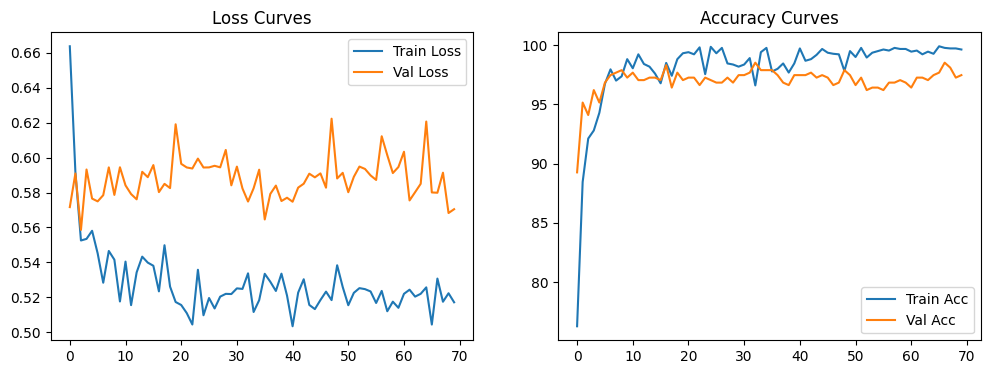

In [6]:
best_val_accuracy = 0
best_val_loss = float('inf')  # Initialize with a large value
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    scheduler.step()
    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch+1}/{epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
    
    # Save model based on best validation accuracy
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), 'best_model_acc.pth')
        print(f'New best accuracy model saved (val_acc: {val_acc:.2f}%)')
    
    # Save model based on best validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_loss.pth')
        print(f'New best loss model saved (val_loss: {val_loss:.4f})')

# Plotting and evaluation
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy Curves')
plt.show()


================= Evaluating Best Val Acc Model =================

Test Accuracy: 98.95%

Classification Report:
              precision    recall  f1-score   support

           C       0.95      0.93      0.94        44
           N       0.99      1.00      0.99       431

    accuracy                           0.99       475
   macro avg       0.97      0.96      0.97       475
weighted avg       0.99      0.99      0.99       475


Per-class Metrics:
C               - Precision: 0.9535, Recall: 0.9318, F1: 0.9425 Accuracy: 93.18%
N               - Precision: 0.9931, Recall: 0.9954, F1: 0.9942 Accuracy: 99.54%

Overall Metrics (Macro-average):
Precision: 0.9733
Recall: 0.9636
F1 Score: 0.9684


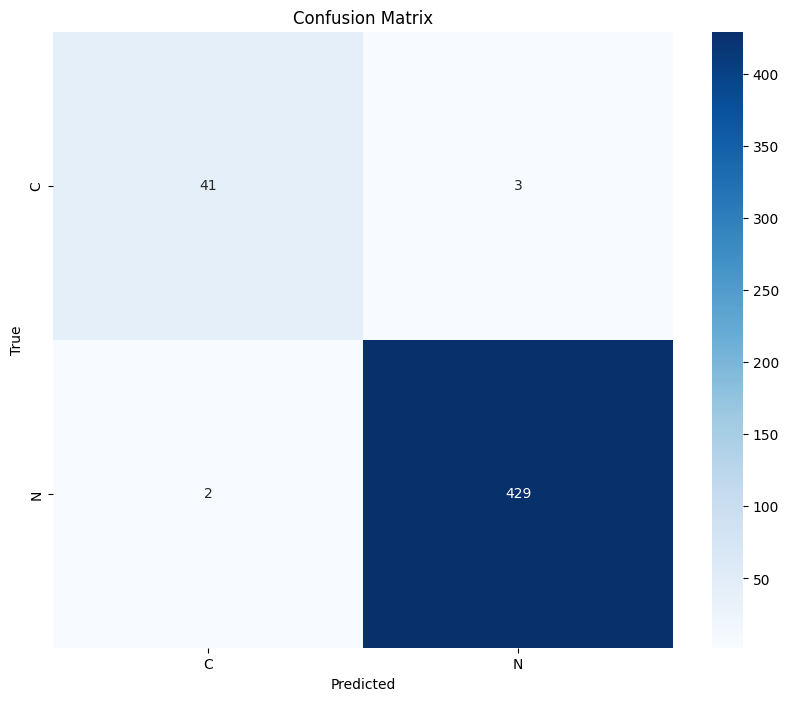


Val Accuracy: 98.53%

Classification Report(on validaition):
              precision    recall  f1-score   support

           C       0.95      0.89      0.92        44
           N       0.99      1.00      0.99       431

    accuracy                           0.99       475
   macro avg       0.97      0.94      0.95       475
weighted avg       0.99      0.99      0.99       475


Per-class Metrics:
C               - Precision: 0.9512, Recall: 0.8864, F1: 0.9176 Accuracy: 88.64%
N               - Precision: 0.9885, Recall: 0.9954, F1: 0.9919 Accuracy: 99.54%

Overall Metrics (Macro-average):
Precision: 0.9698
Recall: 0.9409
F1 Score: 0.9548


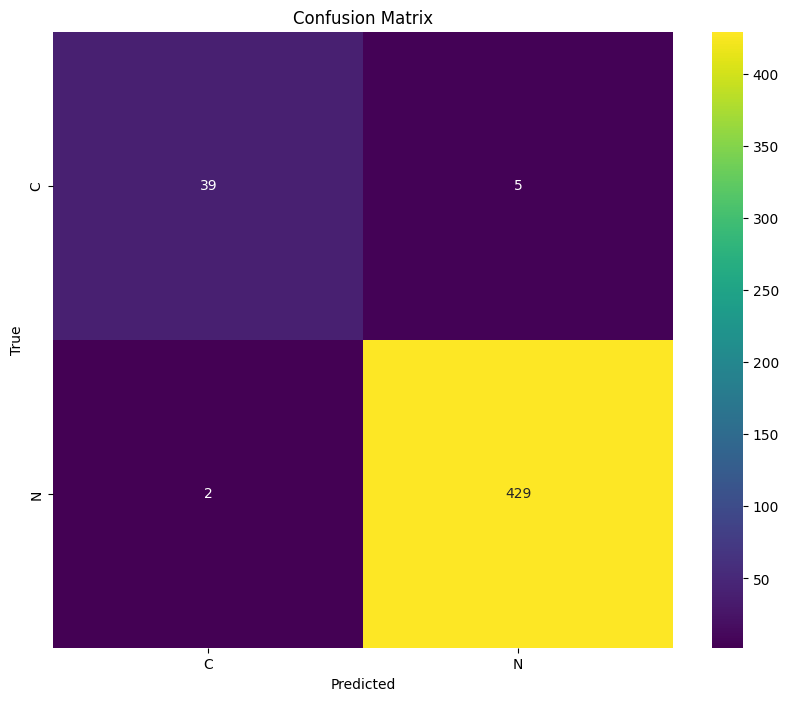


Showing sample test images with actual and predicted labels:


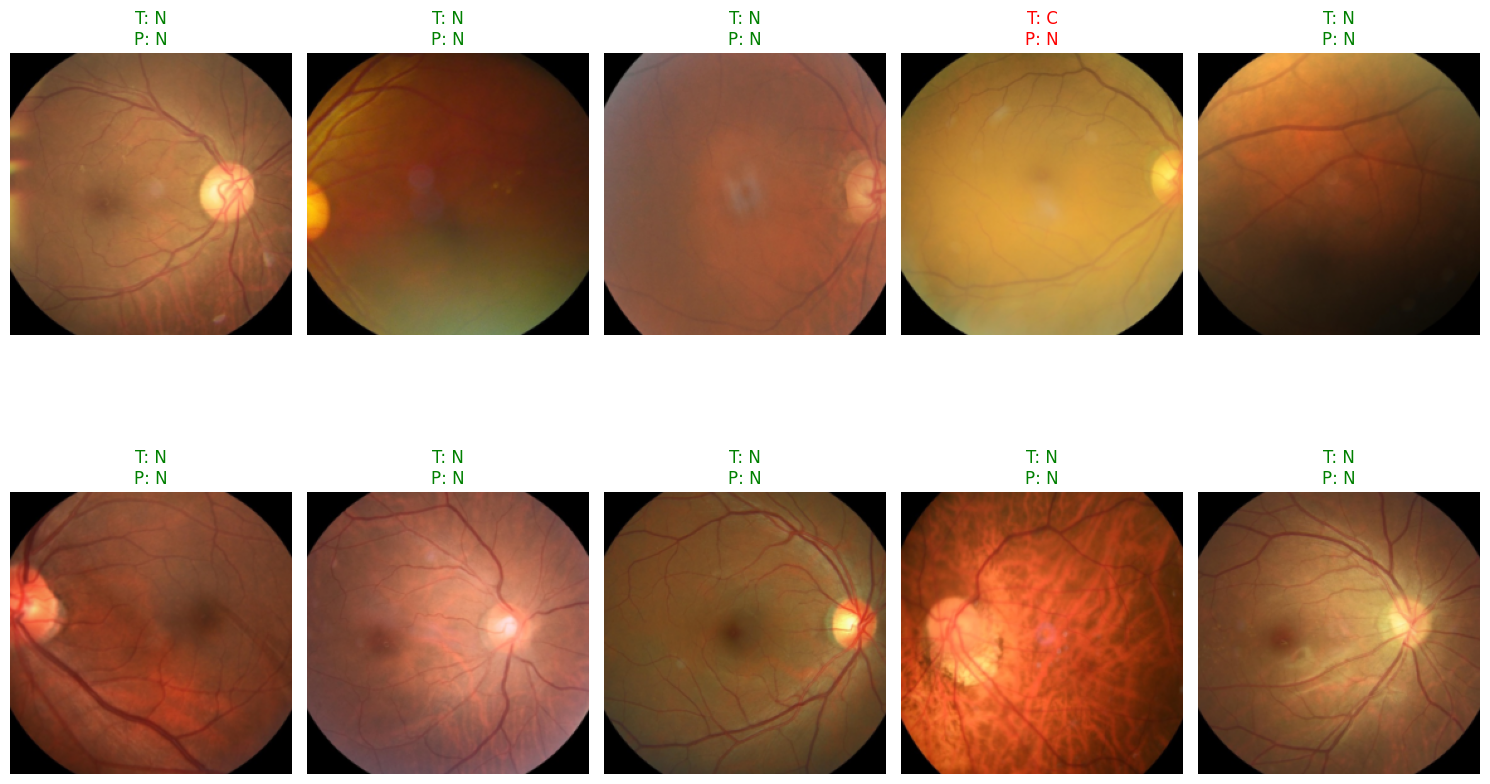

In [7]:
print("\n================= Evaluating Best Val Acc Model =================")
from sklearn.metrics import classification_report, precision_recall_fscore_support
# Load best model and evaluate
model.load_state_dict(torch.load('best_model_acc.pth'))
model.eval()
# Test evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1

        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
test_acc = 100 * test_correct / test_total
print(f'\nTest Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(test_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

    # Per-class accuracy
    # print(f"{class_name:15s} - ")


# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Val evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []
model.load_state_dict(torch.load('best_model_acc.pth'))
model.eval()
# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nVal Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report(on validaition):")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(val_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



############################# Plotting Predicted Images #############################
import matplotlib.pyplot as plt
import torch
import numpy as np
import torchvision
model.load_state_dict(torch.load('best_model_acc.pth'))
# Function to show a batch of images with predicted vs true labels
# Function to show a batch of images with predicted vs true labels
def show_predictions(images, true_labels, pred_labels, class_names, num_images=6):
    images = images.cpu()
    
    # Adjust the number of rows and columns
    num_rows = 2  # Number of rows
    num_columns = num_images // num_rows  # Number of images per row

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 10))  # Adjust the figure size
    axs = axs.flatten()  # Flatten the axis array for easy indexing

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
        img = np.clip(img, 0, 1)
        
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
                         color="green" if true_labels[i] == pred_labels[i] else "red")
    
    plt.tight_layout()
    plt.show()

# Show a few images from the test set
print("\nShowing sample test images with actual and predicted labels:")

# Get class names from dataset
class_names = test_dataset.dataset.classes  # <-- This was missing

# Iterate one batch (or more, as needed)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        show_predictions(inputs, labels, predicted, class_names, num_images=10)  # <-- Fixed variable name
        break  # Remove this break if you want to display multiple batches


================= Evaluating Best Val Loss Model =================

Test Accuracy: 93.89%

Classification Report:
              precision    recall  f1-score   support

           C       0.61      0.95      0.74        44
           N       1.00      0.94      0.97       431

    accuracy                           0.94       475
   macro avg       0.80      0.95      0.85       475
weighted avg       0.96      0.94      0.94       475


Per-class Metrics:
C               - Precision: 0.6087, Recall: 0.9545, F1: 0.7434 Accuracy: 95.45%
N               - Precision: 0.9951, Recall: 0.9374, F1: 0.9654 Accuracy: 93.74%

Overall Metrics (Macro-average):
Precision: 0.8019
Recall: 0.9460
F1 Score: 0.8544


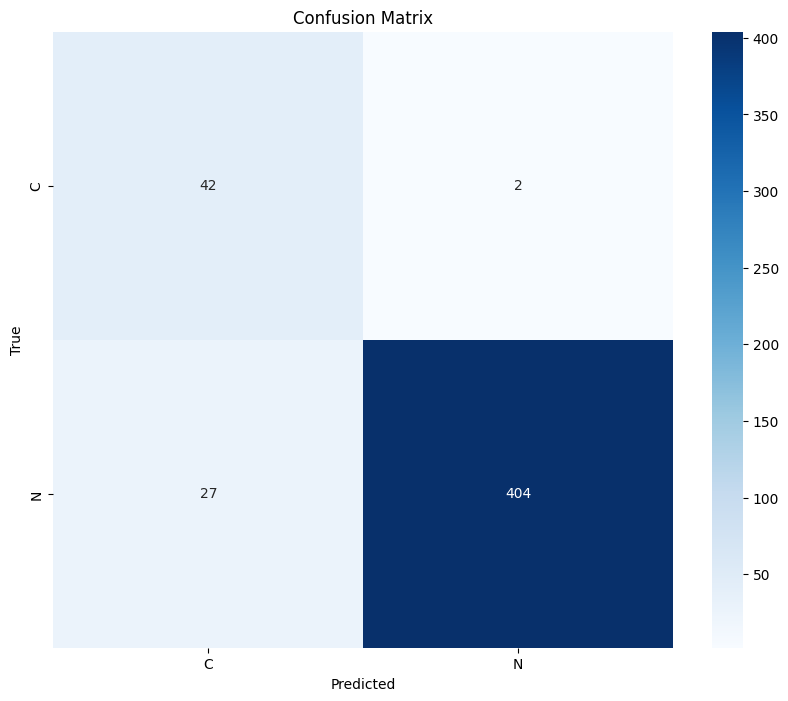


Val Accuracy: 94.11%

Classification Report(on validaition):
              precision    recall  f1-score   support

           C       0.61      0.98      0.75        44
           N       1.00      0.94      0.97       431

    accuracy                           0.94       475
   macro avg       0.81      0.96      0.86       475
weighted avg       0.96      0.94      0.95       475


Per-class Metrics:
C               - Precision: 0.6143, Recall: 0.9773, F1: 0.7544 Accuracy: 97.73%
N               - Precision: 0.9975, Recall: 0.9374, F1: 0.9665 Accuracy: 93.74%

Overall Metrics (Macro-average):
Precision: 0.8059
Recall: 0.9573
F1 Score: 0.8604


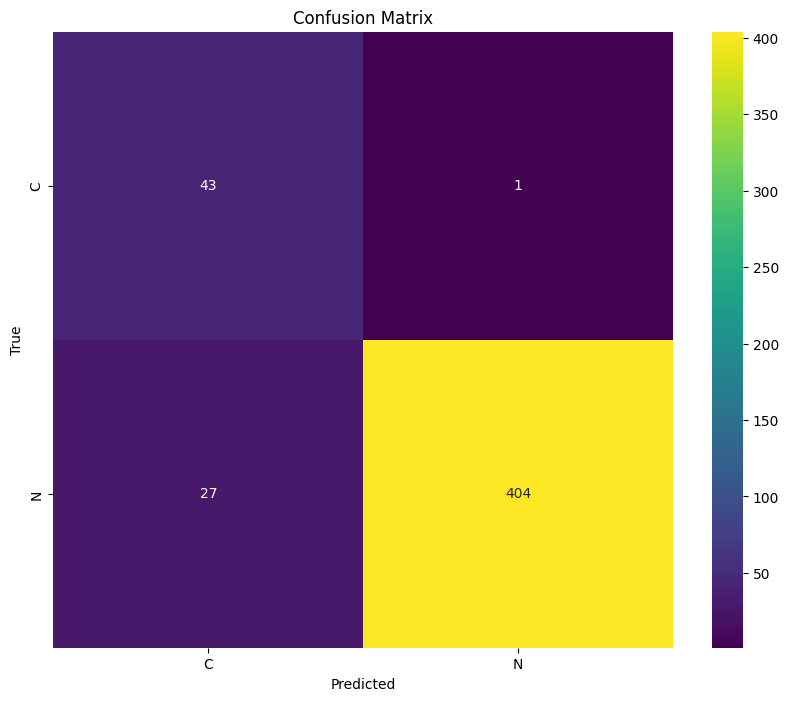


Showing sample test images with actual and predicted labels:


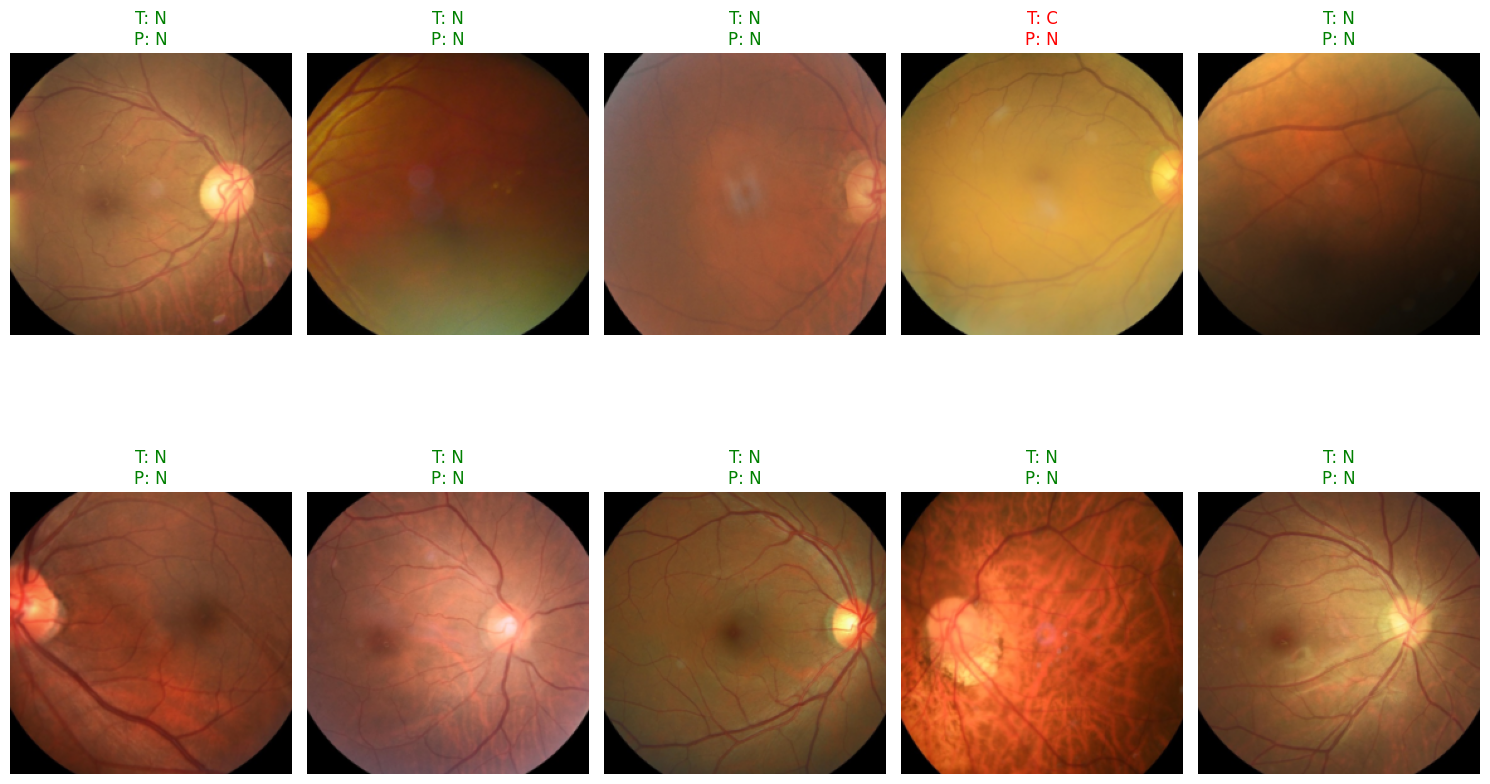

In [8]:
print("\n================= Evaluating Best Val Loss Model =================")
from sklearn.metrics import classification_report, precision_recall_fscore_support
# Load best model and evaluate
model.load_state_dict(torch.load('best_model_loss.pth'))
model.eval()
# Test evaluation
test_correct = 0
test_total = 0
y_true = []
y_pred = []

# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1

        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        
test_acc = 100 * test_correct / test_total
print(f'\nTest Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=test_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(test_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

    # Per-class accuracy
    # print(f"{class_name:15s} - ")


# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

####################### Val evaluation #############################
test_correct = 0
test_total = 0
y_true = []
y_pred = []
model.load_state_dict(torch.load('best_model_loss.pth'))
model.eval()
# Per-class correct counts and totals for accuracy calculation
class_correct = [0] * len(test_dataset.dataset.classes)
class_total = [0] * len(test_dataset.dataset.classes)

with torch.no_grad():
    model.eval()  # Set model to evaluation mode
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Track per-class correct predictions and total samples
        for i in range(labels.size(0)):
            label = labels[i]
            class_total[label] += 1
            if predicted[i] == label:
                class_correct[label] += 1
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

test_acc = 100 * test_correct / test_total
print(f'\nVal Accuracy: {test_acc:.2f}%')

# Detailed classification report
print("\nClassification Report(on validaition):")
print(classification_report(y_true, y_pred, target_names=val_dataset.dataset.classes))

# Per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None)
print("\nPer-class Metrics:")
for i, class_name in enumerate(val_dataset.dataset.classes):
    per_class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    print(f"{class_name:15s} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1: {f1[i]:.4f} Accuracy: {per_class_acc:.2f}%")

# Overall metrics (macro-average)
overall_precision, overall_recall, overall_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
print(f"\nOverall Metrics (Macro-average):")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1 Score: {overall_f1:.4f}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis',
            xticklabels=test_dataset.dataset.classes, 
            yticklabels=test_dataset.dataset.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


############################# Plotting Predicted Images #############################
import matplotlib.pyplot as plt
import torch
import numpy as np
import torchvision
model.load_state_dict(torch.load('best_model_loss.pth'))
# Function to show a batch of images with predicted vs true labels
def show_predictions(images, true_labels, pred_labels, class_names, num_images=6):
    images = images.cpu()
    
    # Adjust the number of rows and columns
    num_rows = 2  # Number of rows
    num_columns = num_images // num_rows  # Number of images per row

    fig, axs = plt.subplots(num_rows, num_columns, figsize=(15, 10))  # Adjust the figure size
    axs = axs.flatten()  # Flatten the axis array for easy indexing

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
        img = np.clip(img, 0, 1)
        
        axs[i].imshow(img)
        axs[i].axis('off')
        axs[i].set_title(f"T: {class_names[true_labels[i]]}\nP: {class_names[pred_labels[i]]}",
                         color="green" if true_labels[i] == pred_labels[i] else "red")
    
    plt.tight_layout()
    plt.show()

# Show a few images from the test set
print("\nShowing sample test images with actual and predicted labels:")

# Iterate one batch (or more, as needed)
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        show_predictions(inputs, labels, predicted, class_names, num_images=10)
        break  # Remove this break if you want to display multiple batches

In [9]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torchvision import models, transforms
# from sklearn.metrics import classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns
# import numpy as np

# # Check for GPU availability


# # Initialize datasets and dataloaders (replace with your actual datasets)
# # train_dataset = YourDataset(..., transform=train_transform)
# # val_dataset = YourDataset(..., transform=val_transform)
# # test_dataset = YourDataset(..., transform=val_transform)

# # Calculate class weights if imbalanced
# # class_counts = ... # calculate from your dataset
# # class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
# # class_weights = class_weights / class_weights.sum() * len(class_counts)
# # class_weights = class_weights.to(device)

# # Initialize model
# model = models.resnet50(pretrained=True)

# # Freeze earlier layers, fine-tune later ones with more conservative approach
# for param in model.parameters():
#     param.requires_grad = False

# # Unfreeze last two blocks gradually
# for param in model.layer3.parameters():
#     param.requires_grad = True
# for param in model.layer4.parameters():
#     param.requires_grad = True

# # Enhanced head with more aggressive regularization
# model.fc = nn.Sequential(
#     nn.Linear(2048, 1024),
#     nn.BatchNorm1d(1024),
#     nn.ReLU(),
#     nn.Dropout(0.6),  # Increased dropout
#     nn.Linear(1024, 512),
#     nn.BatchNorm1d(512),
#     nn.ReLU(),
#     nn.Dropout(0.4),
#     nn.Linear(512, num_classes)
# )

# model = model.to(device)

# # Loss with stronger label smoothing
# criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.2)

# # Optimizer with weight decay and smaller learning rate
# optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-3)

# # Cosine annealing learning rate scheduler
# scheduler = optim.lr_scheduler.CosineAnnealingLR(
#     optimizer, 
#     T_max=70*len(train_loader),  # Adjust based on your epochs
#     eta_min=1e-6
# )

# # Training parameters
# epochs = 70
# early_stopping_patience = 7
# best_val_accuracy = 0
# best_val_loss = float('inf')
# epochs_without_improvement = 0

# # Tracking metrics
# train_losses, val_losses = [], []
# train_accs, val_accs = [], []
# lr_history = []

# # Training loop with enhanced validation
# for epoch in range(epochs):
#     model.train()
#     running_loss = 0.0
#     correct = 0
#     total = 0
    
#     for inputs, labels in train_loader:
#         inputs, labels = inputs.to(device), labels.to(device)
        
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
        
#         # Gradient clipping with smaller norm
#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
#         optimizer.step()
        
#         running_loss += loss.item()
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
    
#     train_loss = running_loss / len(train_loader)
#     train_acc = 100 * correct / total
#     train_losses.append(train_loss)
#     train_accs.append(train_acc)
    
#     # Validation phase
#     model.eval()
#     val_loss = 0.0
#     val_correct = 0
#     val_total = 0
#     all_preds = []
#     all_labels = []
    
#     with torch.no_grad():
#         for inputs, labels in val_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             val_loss += loss.item()
            
#             _, predicted = torch.max(outputs.data, 1)
#             val_total += labels.size(0)
#             val_correct += (predicted == labels).sum().item()
            
#             all_preds.extend(predicted.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
    
#     val_loss /= len(val_loader)
#     val_acc = 100 * val_correct / val_total
#     val_losses.append(val_loss)
#     val_accs.append(val_acc)
    
#     # Update learning rate
#     scheduler.step()
#     lr_history.append(optimizer.param_groups[0]['lr'])
    
#     print(f'Epoch {epoch+1}/{epochs}:')
#     print(f'Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%')
#     print(f'Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%')
#     print(f'LR: {optimizer.param_groups[0]["lr"]:.2e}')
    
#     # Enhanced early stopping condition
#     if val_acc > best_val_accuracy and val_loss < best_val_loss:
#         best_val_accuracy = val_acc
#         best_val_loss = val_loss
#         torch.save(model.state_dict(), 'best_model.pth')
#         epochs_without_improvement = 0
#         print(f'New best model saved (Acc: {val_acc:.2f}%, Loss: {val_loss:.4f})')
#     else:
#         epochs_without_improvement += 1
#         if epochs_without_improvement >= early_stopping_patience:
#             print(f'Early stopping triggered after {epoch+1} epochs')
#             break

# # Plotting training curves
# plt.figure(figsize=(18, 6))

# # Loss curves
# plt.subplot(1, 3, 1)
# plt.plot(train_losses, label='Train Loss')
# plt.plot(val_losses, label='Val Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Loss Curves')
# plt.legend()

# # Accuracy curves
# plt.subplot(1, 3, 2)
# plt.plot(train_accs, label='Train Acc')
# plt.plot(val_accs, label='Val Acc')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy (%)')
# plt.title('Accuracy Curves')
# plt.legend()

# # Learning rate schedule
# plt.subplot(1, 3, 3)
# plt.plot(lr_history, label='Learning Rate')
# plt.xlabel('Epoch')
# plt.ylabel('LR')
# plt.title('Learning Rate Schedule')
# plt.legend()

# plt.tight_layout()
# plt.show()



In [10]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from torch.utils.data import Subset, DataLoader
# from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# # Evaluation Function for Subset-based Datasets
# def evaluate_model(model, dataloader, dataset_name='Test'):
#     model.eval()
#     correct = 0
#     total = 0
#     all_preds = []
#     all_labels = []
    
#     # Get the original dataset from the Subset
#     original_dataset = dataloader.dataset.dataset if isinstance(dataloader.dataset, Subset) else dataloader.dataset
#     class_names = original_dataset.classes
#     num_classes = len(class_names)
    
#     # Initialize per-class counters
#     class_correct = [0] * num_classes
#     class_total = [0] * num_classes
    
#     with torch.no_grad():
#         for inputs, labels in dataloader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs.data, 1)
            
#             total += labels.size(0)
#             correct += (predicted == labels).sum().item()
            
#             # Track per-class metrics
#             for i in range(labels.size(0)):
#                 label = labels[i].item()  # Convert to Python int
#                 class_total[label] += 1
#                 if predicted[i].item() == label:
#                     class_correct[label] += 1
            
#             all_preds.extend(predicted.cpu().numpy())
#             all_labels.extend(labels.cpu().numpy())
    
#     accuracy = 100 * correct / total
#     print(f'\n{dataset_name} Accuracy: {accuracy:.2f}%')
#     print(f'{dataset_name} Samples: {total}')
    
#     # Classification report
#     print("\nClassification Report:")
#     print(classification_report(
#         all_labels, 
#         all_preds, 
#         target_names=class_names,
#         digits=4
#     ))
    
#     # Per-class metrics
#     precision, recall, f1, _ = precision_recall_fscore_support(
#         all_labels, all_preds, average=None
#     )
#     print("\nPer-class Metrics:")
#     for i, class_name in enumerate(class_names):
#         class_acc = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
#         print(f"{class_name:15s} - Prec: {precision[i]:.4f}, Rec: {recall[i]:.4f}, F1: {f1[i]:.4f}, Acc: {class_acc:.2f}% (n={class_total[i]})")
    
#     # Confusion matrix
#     plt.figure(figsize=(12, 10))
#     sns.heatmap(
#         confusion_matrix(all_labels, all_preds), 
#         annot=True, 
#         fmt='d', 
#         cmap='Blues',
#         xticklabels=class_names,
#         yticklabels=class_names
#     )
#     plt.xlabel('Predicted')
#     plt.ylabel('True')
#     plt.title(f'{dataset_name} Confusion Matrix')
#     plt.xticks(rotation=45)
#     plt.yticks(rotation=0)
#     plt.tight_layout()
#     plt.show()
    
#     return accuracy

# # Visualization Function
# def show_predictions(images, true_labels, pred_labels, class_names, num_images=8):
#     images = images.cpu()
#     plt.figure(figsize=(15, 10))
    
#     num_cols = min(4, num_images)
#     num_rows = (num_images + num_cols - 1) // num_cols
    
#     for i in range(min(num_images, len(images))):
#         plt.subplot(num_rows, num_cols, i+1)
#         img = images[i].permute(1, 2, 0).numpy()
#         img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]  # De-normalize
#         img = np.clip(img, 0, 1)
        
#         plt.imshow(img)
#         plt.axis('off')
#         plt.title(f"True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}",
#                  color="green" if true_labels[i] == pred_labels[i] else "red",
#                  fontsize=10)
    
#     plt.tight_layout()
#     plt.show()

# # Evaluation Pipeline
# def run_evaluation_pipeline(model, val_loader, test_loader):
#     print("\n================= Evaluating Best Model =================")
#     model.load_state_dict(torch.load('best_model.pth'))
    
#     # Get class names from original dataset
#     original_dataset = val_loader.dataset.dataset if isinstance(val_loader.dataset, Subset) else val_loader.dataset
#     class_names = original_dataset.classes
    
#     # Evaluate on validation set
#     print("\n=== Validation Set Evaluation ===")
#     val_accuracy = evaluate_model(model, val_loader, 'Validation')
    
#     # Evaluate on test set
#     print("\n=== Test Set Evaluation ===")
#     test_accuracy = evaluate_model(model, test_loader, 'Test')
    
#     # Display sample predictions from both sets
#     print("\n=== Sample Validation Predictions ===")
#     with torch.no_grad():
#         for inputs, labels in val_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs, 1)
#             show_predictions(inputs, labels, predicted, class_names)
#             break
    
#     print("\n=== Sample Test Predictions ===")
#     with torch.no_grad():
#         for inputs, labels in test_loader:
#             inputs, labels = inputs.to(device), labels.to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs, 1)
#             show_predictions(inputs, labels, predicted, class_names)
#             break
    
#     return val_accuracy, test_accuracy

# # Run the evaluation
# val_acc, test_acc = run_evaluation_pipeline(model, val_loader, test_loader)